<a href="https://colab.research.google.com/github/harshitasdev8/Figure_Creation_Oda/blob/Reg_Gene/Figures_Project_Regular_Genes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

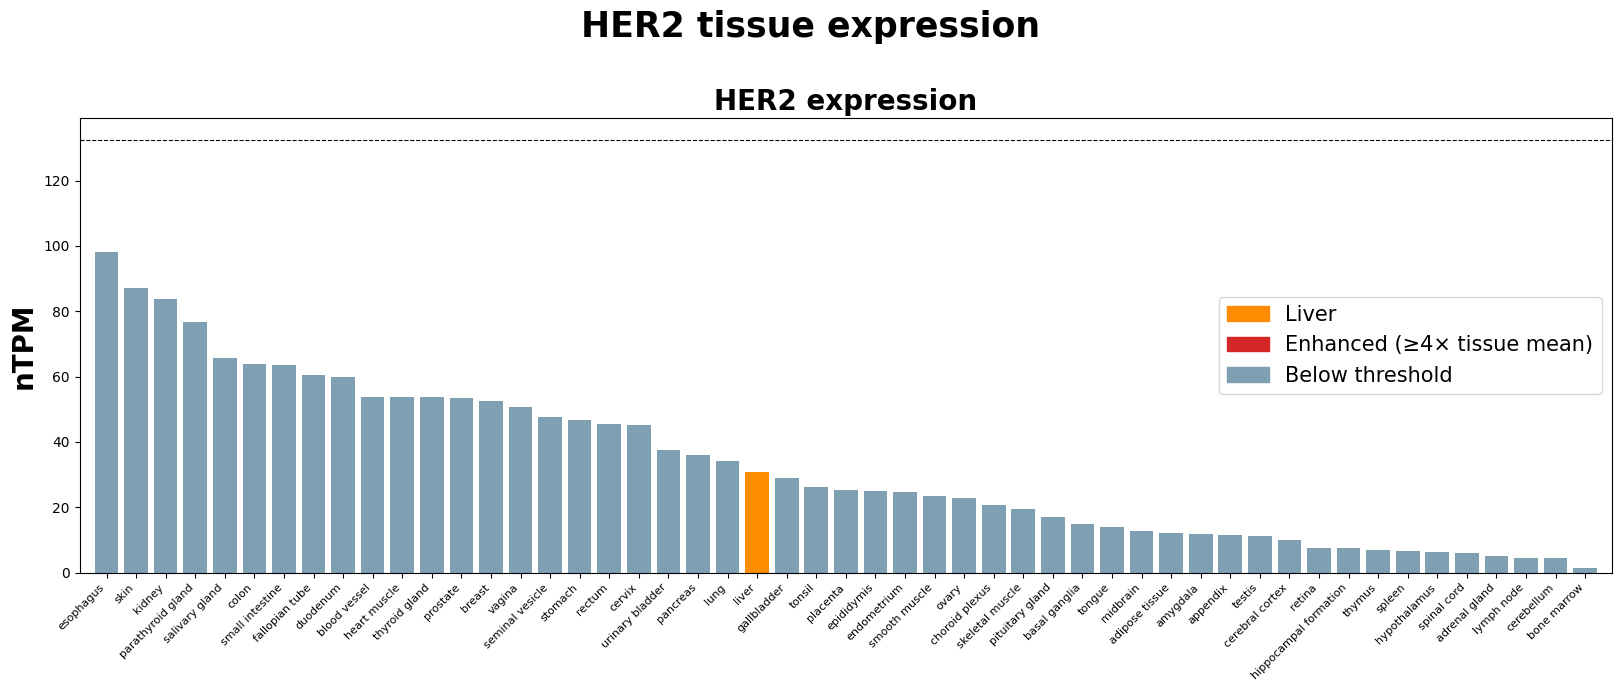

Saved: HER2_expression_zoomed.png
Threshold used: 132.45 nTPM (4x mean of 33.11)


In [ ]:
"""
Bar chart visualization for tissue expression data.
To reuse with other datasets: only edit the CONFIG block.
"""
import openpyxl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ============ CONFIG — edit this block for new datasets ============
INPUT_FILE       = "/content/ERBB2_Data.xlsx"
SHEET_NAME       = "Sheet1"         # None = first sheet
LABEL_COL        = "Tissue"         # column header for the category labels
VALUE_COL        = "nTPM"           # column header for the numeric values
TITLE_LABEL      = "HER2"          # used in chart titles (e.g. gene name)
VALUE_LABEL      = "nTPM"           # used as axis label
HIGHLIGHT_TISSUE = "liver"          # tissue to call out regardless of threshold
FOLD_THRESHOLD   = 4                # HPA's "Enhanced" multiplier — same for every gene
OUTPUT_FILE      = "HER2_expression_zoomed.png"
# =====================================================================

def load_data(path, sheet, label_col, value_col):
    wb = openpyxl.load_workbook(path, data_only=True)
    ws = wb[sheet] if sheet else wb[wb.sheetnames[0]]
    rows = list(ws.iter_rows(values_only=True))
    header, data_rows = rows[0], rows[1:]
    li, vi = header.index(label_col), header.index(value_col)
    data = [(r[li], r[vi]) for r in data_rows if r[li] is not None and r[vi] is not None]

    # sort descending by value
    data.sort(key=lambda x: x[1], reverse=True)
    return data

def plot(data, fold_threshold, highlight_tissue, title_label, value_label, output_file):
    labels_all = [d[0] for d in data]
    values_all = [d[1] for d in data]
    n_all = len(data)

    # threshold recomputed from this gene's own data — not hardcoded
    threshold = fold_threshold * (sum(values_all) / n_all)

    colors = []
    for label, val in zip(labels_all, values_all):
        if label.lower() == highlight_tissue.lower():
            colors.append("#FF8C00")          # liver: distinct color, always
        elif val >= threshold:
            colors.append("#d62728")          # Enhanced
        else:
            colors.append("#7f9fb2")          # below threshold

    fig, ax = plt.subplots(figsize=(max(14, n_all * 0.32), 7))
    ax.bar(range(n_all), values_all, color=colors, width=0.8)
    ax.set_xticks(range(n_all))
    ax.set_xticklabels(labels_all, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel(value_label, fontsize=20, fontweight="bold")
    ax.set_title(f"{title_label} expression", fontsize=20, fontweight="bold")
    ax.axhline(threshold, color="black", linestyle="--", linewidth=0.8)
    ax.margins(x=0.01)

    fig.suptitle(f"{title_label} tissue expression", fontsize=25, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.96])

    handles = [
        mpatches.Patch(color="#FF8C00", label=highlight_tissue.capitalize()),
        mpatches.Patch(color="#d62728", label=f"Enhanced (≥{fold_threshold}× tissue mean)"),
        mpatches.Patch(color="#7f9fb2", label="Below threshold"),
    ]
    ax.legend(handles=handles, loc="center right", fontsize=15, frameon=True)

    fig.savefig(output_file, dpi=150)
    plt.show()
    print(f"Saved: {output_file}")
    print(f"Threshold used: {threshold:.2f} nTPM ({fold_threshold}x mean of {sum(values_all)/n_all:.2f})")

data = load_data(INPUT_FILE, SHEET_NAME, LABEL_COL, VALUE_COL)
plot(data, FOLD_THRESHOLD, HIGHLIGHT_TISSUE, TITLE_LABEL, VALUE_LABEL, OUTPUT_FILE)